<a href="https://colab.research.google.com/github/Maevehassett/FINTECH-P0-HASSETT/blob/main/FINA4075_P0_Starter_(5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FINA 4075/5075 — Project 0 Starter Notebook (Fall 2026)

**Before running anything:** File → **Save a copy in Drive**, then Runtime → Change runtime type → **Runtime version 2026.07** (Rule 0).

Follow the Project 0 Detailed Student Instructions (D2L). Run cells top to bottom; finish with **Runtime → Restart session and run all** — it must complete with no errors before you submit.

In [1]:
# Cell 1 — mount Drive (Rule 1)
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Cell 2 — create the course folder
import os
P0 = "/content/drive/MyDrive/FINA4075/P0"
os.makedirs(P0, exist_ok=True)
print("Folder ready:", P0)

Folder ready: /content/drive/MyDrive/FINA4075/P0


In [3]:
# Cell 3 — pinned setup (Rule 2; -q omitted in P0 on purpose)
# Official pinned line (Fall 2026), as posted in D2L (Rule 2).
%pip install yfinance==0.2.66 sec-edgar-downloader==5.1.0

In [4]:
# Cell 4 — environment stamp (Rule 0)
import sys, pandas as pd, numpy as np, matplotlib, yfinance as yf
print(sys.version)
print("pandas", pd.__version__, "| numpy", np.__version__,
      "| matplotlib", matplotlib.__version__, "| yfinance", yf.__version__)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
pandas 2.2.2 | numpy 2.0.2 | matplotlib 3.10.0 | yfinance 0.2.66


In [5]:
# Cell 5 — seeded synthetic data: 60 trading days of two synthetic ETFs
rng = np.random.default_rng(4075)
spyx = 100 * np.cumprod(1 + rng.normal(0.0006, 0.009, 60))
aggx = 100 * np.cumprod(1 + rng.normal(0.0001, 0.002, 60))
print("Data built:", len(spyx), "days")

Data built: 60 days


In [6]:
# Cell 6 — the two-row summary table (must match the instructions exactly)
def stats(x):
    total = x[-1] / 100 - 1
    daily = np.diff(x) / x[:-1]
    vol = daily.std(ddof=1) * (252 ** 0.5)
    return round(x[-1], 2), round(total * 100, 2), round(vol * 100, 2)
summary = pd.DataFrame(
    [stats(spyx), stats(aggx)],
    index=["SPYX (synthetic equity ETF)", "AGGX (synthetic bond ETF)"],
    columns=["End value of $100", "Total return %", "Annualized vol %"])
print(summary)

                             End value of $100  Total return %  \
SPYX (synthetic equity ETF)             109.51            9.51   
AGGX (synthetic bond ETF)               100.54            0.54   

                             Annualized vol %  
SPYX (synthetic equity ETF)             13.30  
AGGX (synthetic bond ETF)                2.97  


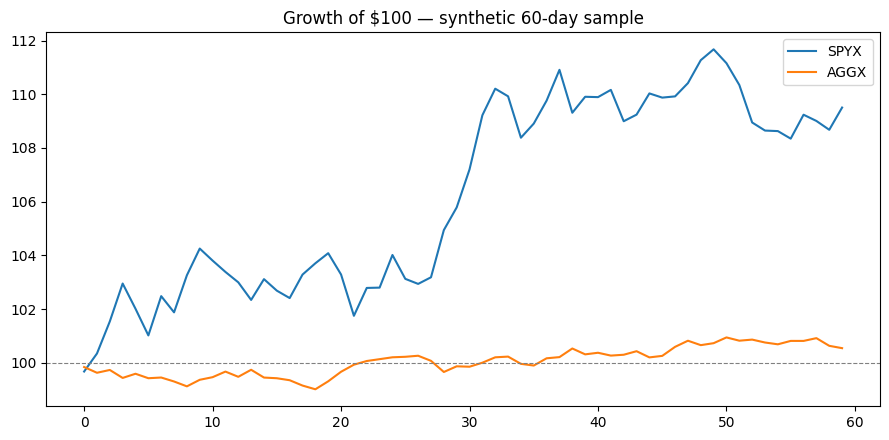

In [7]:
# Cell 7 — the growth-of-$100 chart
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(spyx, label="SPYX"); ax.plot(aggx, label="AGGX")
ax.axhline(100, ls="--", lw=0.8, color="gray")
ax.set_title("Growth of $100 — synthetic 60-day sample")
ax.legend(); plt.tight_layout()
plt.show()

In [8]:
# Cell 8 — save outputs to Drive (Rule 7)
summary.to_csv(f"{P0}/p0_summary.csv")
fig.savefig(f"{P0}/p0_chart.png", dpi=150)
print("Saved 2 files to", P0)

Saved 2 files to /content/drive/MyDrive/FINA4075/P0


**Done?** Expected: SPYX \$109.51 · AGGX \$100.54. Now **Runtime → Restart session and run all**, take your four screenshots per the instructions, save this notebook to your GitHub repo (File → Save a copy in GitHub), and submit the PDF to the D2L Project 0 dropbox.